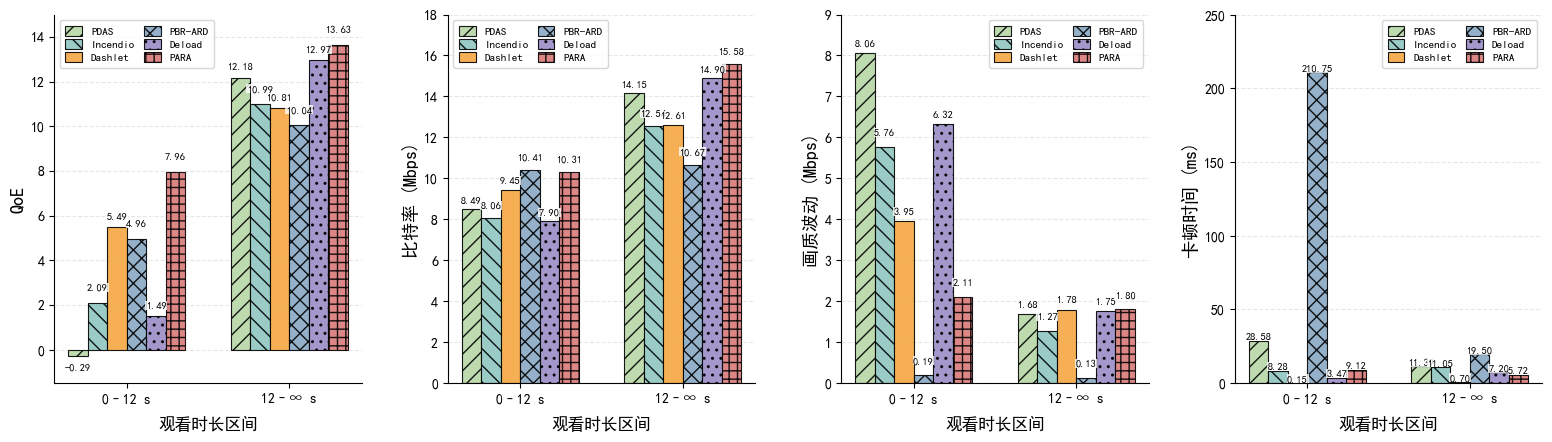

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 数据
# =========================

algorithms = ['PDAS', 'Incendio', 'Dashlet',
              'PBR-ARD', 'Deload', 'PARA']

stages = ['0–12 s', '12–∞ s']

# QoE
qoe = {
    'PDAS':     [-0.29, 12.18],
    'Incendio': [ 2.09, 10.99],
    'Dashlet':  [ 5.49, 10.81],
    'PBR-ARD':  [ 4.96, 10.04],
    'Deload':   [ 1.49, 12.97],
    'PARA':     [ 7.96, 13.63]
}

# 平均比特率
bitrate = {
    'PDAS':     [ 8.49, 14.15],
    'Incendio': [ 8.06, 12.54],
    'Dashlet':  [ 9.45, 12.61],
    'PBR-ARD':  [10.41, 10.67],
    'Deload':   [ 7.90, 14.90],
    'PARA':     [10.31, 15.58]
}

# 画质波动
fluctuation = {
    'PDAS':     [8.06, 1.68],
    'Incendio': [5.76, 1.27],
    'Dashlet':  [3.95, 1.78],
    'PBR-ARD':  [0.19, 0.13],
    'Deload':   [6.32, 1.75],
    'PARA':     [2.11, 1.80]
}

# 卡顿时间
rebuff = {
    'PDAS':     [28.58, 11.39],
    'Incendio': [8.28, 11.05],
    'Dashlet':  [0.15, 0.70],
    'PBR-ARD': [210.75, 19.50],
    'Deload':   [3.47, 7.20],
    'PARA':     [9.12, 5.72]
}

# =========================
# 绘图参数
# =========================

x = np.arange(len(stages))
width = 0.12

colors = [
    '#B7D7A8',
    '#8FC6C0',
    '#F5A742',
    '#88A9C4',
    '#9A8CC7',
    '#D97979'
]

hatches = ['//', '\\\\', '', 'xx', '..', '++']


# =========================
# 创建四个子图
# =========================

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 5.5)
)


# =========================
# 绘图函数
# =========================

def draw_subplot(ax, data, ylabel, ylim, label_offset):

    for i, algorithm in enumerate(algorithms):

        offset = (i - (len(algorithms) - 1) / 2) * width

        values = data[algorithm]

        bars = ax.bar(
            x + offset,
            values,
            width=width,
            label=algorithm,
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            hatch=hatches[i],
            alpha=0.9
        )

        # =========================
        # 数值标签
        # =========================

        for stage_idx, (bar, value) in enumerate(zip(bars, values)):

            if value >= 0:
                label_y = value + label_offset
                va = 'bottom'
            else:
                label_y = value - label_offset
                va = 'top'

            # 交错放置数字
            if i % 2 == 1:
                if value >= 0:
                    label_y += label_offset * 0.7
                else:
                    label_y -= label_offset * 0.7

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                label_y,
                f'{value:.2f}',
                ha='center',
                va=va,
                fontsize=7.5,
                bbox=dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.8,
                    pad=0.4
                )
            )

    # =========================
    # 坐标轴
    # =========================

    ax.set_xticks(x)
    ax.set_xticklabels(stages, fontsize=11)

    ax.set_xlabel(
        '观看时长区间',
        fontsize=12,
        labelpad=8
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13
    )

    ax.tick_params(
        axis='both',
        labelsize=10
    )

    # 网格
    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.set_axisbelow(True)

    # 边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 纵轴范围
    ax.set_ylim(ylim)

    # =========================
    # 图例
    # =========================

    ax.legend(
        fontsize=8,
        frameon=True,
        ncol=2,
        handlelength=1.5,
        handleheight=1.0,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.5
    )


# =========================
# 四个子图
# =========================

draw_subplot(
    axes[0],
    qoe,
    'QoE',
    (-1.5, 15),
    0.30
)

draw_subplot(
    axes[1],
    bitrate,
    '比特率 (Mbps)',
    (0, 18),
    0.25
)

draw_subplot(
    axes[2],
    fluctuation,
    '画质波动 (Mbps)',
    (0, 9),
    0.15
)

# ★ 最后一个子图单独调整
draw_subplot(
    axes[3],
    rebuff,
    '卡顿时间 (ms)',
    (0, 250),
    0.05
)


# =========================
# 布局
# =========================

plt.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.15,
    top=0.82,
    wspace=0.28
)

plt.savefig(
    'fig1.svg',
    bbox_inches='tight'
)

plt.show()

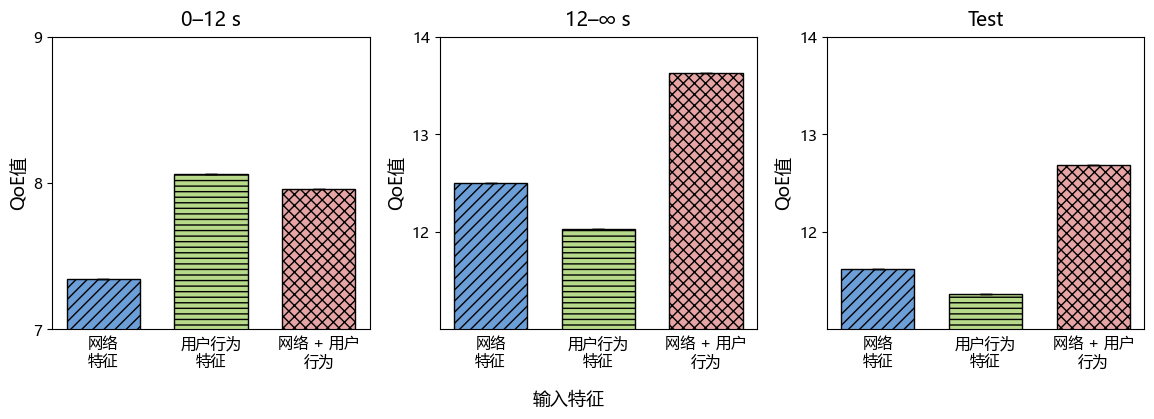

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 中文字体
# =========================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 2. 数据
# =========================
groups = ['0–12 s', '12–∞ s', 'Test']

qoe_data = {
    '0–12 s': [7.34, 8.06, 7.96],
    '12–∞ s': [12.50, 12.03, 13.63],
    'Test':   [11.62, 11.36, 12.68]
}

# 两行显示，避免拥挤
labels = [
    '网络\n特征',
    '用户行为\n特征',
    '网络 + 用户\n行为'
]

# =========================
# 3. 误差数据
# =========================
# 如果没有误差数据，就设置为 0
error_data = {
    '0–12 s': [0, 0, 0],
    '12–∞ s': [0, 0, 0],
    'Test':   [0, 0, 0]
}

# =========================
# 4. 每个子图的 y 轴范围和刻度
# =========================
ylim_dict = {
    '0–12 s': (7, 9),
    '12–∞ s': (11, 14),
    'Test':   (11, 14)
}

yticks_dict = {
    '0–12 s': [7.0, 8.0, 9.0],
    '12–∞ s': [12.0, 13.0, 14.0],
    'Test':   [12.0, 13.0, 14.0]
}
# =========================
# 5. 绘图
# =========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4.3)
)

# 柱子颜色
colors = [
    '#6C9ED8',
    '#B7D98A',
    '#E6A4A4'
]

# 纹理
hatches = [
    '///',
    '---',
    'xxx'
]

for i, group in enumerate(groups):

    ax = axes[i]

    values = qoe_data[group]
    errors = error_data[group]

    x = np.arange(len(labels))

    # -------------------------
    # 柱状图
    # -------------------------
    bars = ax.bar(
        x,
        values,
        width=0.68,
        yerr=errors,
        capsize=4,
        edgecolor='black',
        linewidth=1.0,
        color=colors,
        error_kw={
            'ecolor': 'black',
            'elinewidth': 1.0,
            'capthick': 1.0
        }
    )

    # 添加纹理
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)

    # -------------------------
    # x 轴
    # -------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(
        labels,
        fontsize=11,
        linespacing=1.15
    )

    ax.tick_params(
        axis='x',
        length=0,
        pad=5
    )

    # -------------------------
    # y 轴
    # -------------------------
    ax.set_ylim(*ylim_dict[group])
    ax.set_yticks(yticks_dict[group])

    ax.tick_params(
        axis='y',
        labelsize=11
    )

    # 只有第一个子图显示 y 轴名称
    ax.set_ylabel(
        'QoE值',
        fontsize=13
    )

    # -------------------------
    # 子图标题
    # -------------------------
    ax.set_title(
        group,
        fontsize=14,
        pad=8
    )

    # -------------------------
    # 边框
    # -------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    ax.grid(False)


# =========================
# 6. 整张图统一的 x 轴名称
# =========================
fig.text(
    0.5,
    0.055,
    '输入特征',
    ha='center',
    va='center',
    fontsize=13
)

# =========================
# 7. 调整布局
# =========================
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    bottom=0.22,
    top=0.90,
    wspace=0.22
)

plt.savefig('fig2.svg')
plt.show()

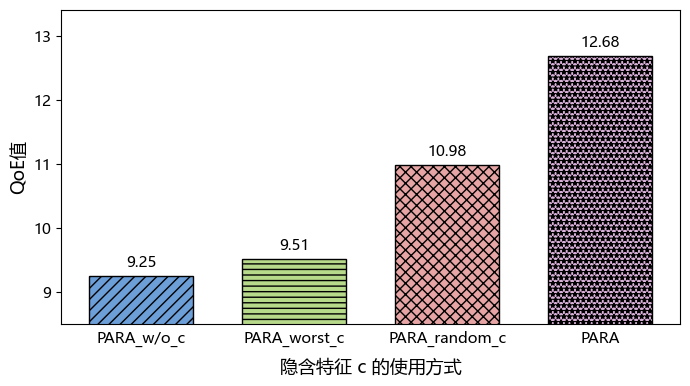

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 中文字体
# =========================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 2. 数据
# =========================
labels = [
        'PARA_w/o_c',
        'PARA_worst_c',
        'PARA_random_c',
        'PARA'
]

qoe = [
    9.25,
    9.51,
    10.98,
    12.68
]

# =========================
# 3. 绘图
# =========================
fig, ax = plt.subplots(
    figsize=(7.2, 4.3)
)

x = np.arange(len(labels))

# 与前面图保持一致
colors = [
    '#6C9ED8',
    '#B7D98A',
    '#E6A4A4',
    '#D8B0D8'
]

hatches = [
    '///',
    '---',
    'xxx',
    '***'
]

bars = ax.bar(
    x,
    qoe,
    width=0.68,
    edgecolor='black',
    linewidth=1.0,
    color=colors
)

# 添加纹理
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# =========================
# 4. 柱子顶部显示数值
# =========================
for bar, value in zip(bars, qoe):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.08,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

# =========================
# 5. X轴
# =========================
ax.set_xticks(x)

ax.set_xticklabels(
    [
        'PARA_w/o_c',
        'PARA_worst_c',
        'PARA_random_c',
        'PARA'
    ],
    fontsize=11,
    linespacing=1.15
)

ax.set_xlabel(
    '隐含特征 c 的使用方式',
    fontsize=13,
    labelpad=8
)

ax.tick_params(
    axis='x',
    length=0,
    pad=5
)

# =========================
# 6. Y轴
# =========================
ax.set_ylabel(
    'QoE值',
    fontsize=13
)

ax.set_ylim(
    8.5,
    13.4
)

ax.set_yticks(
    [9, 10, 11, 12, 13]
)

ax.tick_params(
    axis='y',
    labelsize=11
)

# =========================
# 7. 边框
# =========================
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

ax.grid(False)

# =========================
# 8. 布局
# =========================
plt.subplots_adjust(
    left=0.11,
    right=0.97,
    bottom=0.20,
    top=0.93
)

plt.savefig('fig3.svg')
plt.show()

In [ ]:
# ============================================================
# 观看比例分布
# ============================================================

ratio = data['view_ratio'].values

# 划分 10 个观看比例区间
bins = np.linspace(0, 1, 11)

counts, _ = np.histogram(
    ratio,
    bins=bins
)

percentage = (
    counts / len(ratio) * 100
)

labels = [
    '0–10%',
    '10–20%',
    '20–30%',
    '30–40%',
    '40–50%',
    '50–60%',
    '60–70%',
    '70–80%',
    '80–90%',
    '90–100%'
]


# ============================================================
# 绘图
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

x = np.arange(
    len(labels)
)

bars = ax.bar(
    x,
    percentage,
    width=0.65,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)


# ============================================================
# 数值标签
# ============================================================

for bar, value in zip(
    bars,
    percentage
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 坐标轴
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    labels,
    rotation=30,
    fontsize=10
)

ax.set_xlabel(
    '观看比例 (%)',
    fontsize=12
)

ax.set_ylabel(
    '用户占比 (%)',
    fontsize=12
)

ax.set_title(
    '用户观看比例分布',
    fontsize=13
)


# ============================================================
# 网格
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 保存
# ============================================================

plt.tight_layout()

plt.savefig(
    'user_viewing_ratio.svg',
    bbox_inches='tight'
)
plt.show()